### Basic ChatBot using Langgraph (Graph API)

In [1]:
from typing import Annotated

# Annotated is a Python type hinting mechanism used to define reducer functions that 
# determine how a node's output merges with the existing state.

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

# add_messages is a helper function to add messages to the graph
# it takes a graph and a list of messages and adds them to the graph
# it also adds the START and END states to the graph
# it returns the graph with the messages added



In [2]:
class State(TypedDict):
    # Messages have the type "list". 
    # The `add_messages` function in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(model = "groq:llama-3.1-8b-instant")
llm 

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AD64B0BF20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AD65B0E3C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# Node Functionality

def chatbot(state:State):
    
    return {"messages": [llm.invoke(state["messages"])]}

# This function defines a node in the graph that takes the current state (which includes a list of messages) 
# and returns a new state with an additional message generated by the language model (LLM). 
# The `llm.invoke` method is called with the current messages to generate a response, which is then added to the list of messages in the state.

In [7]:
# Constructing the graph

# Adding nodes to the graph
graph_builder.add_node("llm-Chatbot",chatbot)

# Adding edges to the graph
graph_builder.add_edge(START,"llm-Chatbot")
graph_builder.add_edge("llm-Chatbot",END)

# Compile the graph
graph = graph_builder.compile()

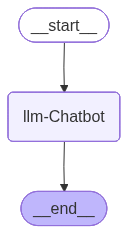

In [8]:
# Visualize the graph

from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    pass

In [9]:
from groq import Groq

client = Groq()
models = client.models.list()

for model in models.data:
    print(model.id)

allam-2-7b
groq/compound-mini
canopylabs/orpheus-v1-english
meta-llama/llama-4-scout-17b-16e-instruct
openai/gpt-oss-safeguard-20b
canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-86m
meta-llama/llama-prompt-guard-2-22m
openai/gpt-oss-120b
qwen/qwen3-32b
groq/compound
llama-3.3-70b-versatile
llama-3.1-8b-instant
openai/gpt-oss-20b
whisper-large-v3
whisper-large-v3-turbo


In [10]:
response = graph.invoke({"messages": "Hello, how are you?"})

In [11]:
response["messages"][-1].content

"I'm functioning properly, thank you for asking. I'm a large language model, so I don't have feelings in the same way humans do, but I'm here to help answer any questions or provide information you need. How can I assist you today?"

### ChatBot with Tools 

In [6]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
   'title': 'Paris facts: the capital of France in history',
   'content': '## Paris facts: Paris, the **capital of France**. Paris is the **capital of France**, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. ## Paris facts: Paris history. From the Romans to the Vth Republic, Paris has a rich 2000 year history. See details of Paris history. ## Paris facts: Paris, a world city. Paris is a world capital city of shopping and fashion, with Channel, Dior, Vuitton, Yves Saint Laurent among many other top french fashion brands. ## Paris facts: the capital of France in history. Before Paris, the capital of France was Lyon (under the Romans). Paris first became the capital of France in 508 under King Clovis. After centuries with no unique capital o

In [31]:
# Custom Function tools (How does llm read the docs string and use it to invoke the tool?)

def multiply(x: int, y: int) -> int:
    """
    Multiply x and y

    Args:
        x (int): first int
        y (int): second int

    Returns:
        int: output int.
    
    """
    return x * y

In [32]:
tools = [tool, multiply]

In [33]:
llm_with_tool = llm.bind_tools(tools)

In [34]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AD64B0BF20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AD65B0E3C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

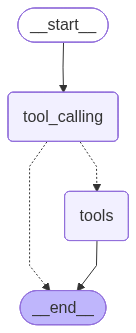

In [35]:
# StateGraph

from langgraph.graph import StateGraph,START,END

from langgraph.prebuilt import ToolNode,tools_condition


# Node Definition

def tool_calling(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

# Graph Construction

builder = StateGraph(State)

builder.add_node("tool_calling", tool_calling)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_calling")
builder.add_conditional_edges(
    "tool_calling",
    
    # If the latest message from the assaistant contains a tool call, the tools condition route to the tool node
    # If not, it routes to the END state

    tools_condition
)

builder.add_edge("tools", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [36]:
response = graph.invoke({"messages": "What is the recent ai news in 5 points?"})

In [37]:
response['messages'][-1].content

'50'

In [38]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news in 5 points?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (nd5s3azd0)
 Call ID: nd5s3azd0
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
  multiply (fysvbr80d)
 Call ID: fysvbr80d
  Args:
    x: 5
    y: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/openai-posts-job-to-prepare-for-self-training-ai-8d180686", "title": "OpenAI posts job to prepare for self-training AI - Let's Data Science", "score": 0.95695716, "published_date": "Sat, 23 May 2026 09:06:58 GMT", "content": "## Scoring Rationale\n\nThe story is a notable signal about industry attention to advanced safety con

In [39]:
response = graph.invoke({"messages": "What is 5 multiplied by 4?"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 4?
================================== Ai Message ==================================
Tool Calls:
  multiply (hajx5kka0)
 Call ID: hajx5kka0
  Args:
    x: 5
    y: 4
================================= Tool Message =================================
Name: multiply

20
